In [27]:
!pip install legacy-cgi

In [28]:
!pip install opendatasets

In [29]:
!pip install torchmetrics

In [30]:
import os
import subprocess
from pathlib import Path
from PIL import Image
## dataset and Visualization
import numpy as np
import pandas as np
import matplotlib.pyplot as plt
import opendatasets as od
import random
## Torch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchmetrics
##Torchvision
from torchvision import datasets,transforms

In [31]:
repo_name = "machine-learning-projects"
repo_path = f'/content/{repo_name}'
repo_url = f"https://github.com/Ebenezeragyemang10/{repo_name}"
sub_working_dir = "chest-x-ray-classification-cnn"


if not os.path.isdir(repo_path):
  print("cloning")
  subprocess.run(["git", "clone", repo_url])

else:
  print("directory already exist....")


target_dir = os.path.join(repo_path, sub_working_dir) if sub_working_dir else repo_path
os.chdir(target_dir)

directory already exist....


In [32]:
od.download("https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data",

)


Skipping, found downloaded files in "./chest-xray-pneumonia" (use force=True to force download)


In [33]:
dataset_dir = f'{target_dir}/chest-xray-pneumonia/chest_xray'
train_dir = f'{dataset_dir}/train'
test_dir = f'{dataset_dir}/test'
valid_dir = f'{dataset_dir}/val'


In [34]:
## Visualize the data

In [35]:
print(f"Total training normal xrays: {len(os.listdir(train_dir + "/NORMAL"))}")
print(f"Total training Pneumonia xrays: {len(os.listdir(train_dir + "/PNEUMONIA"))}")
print(f"Total testing normal xrays: {len(os.listdir(test_dir + "/NORMAL"))}")
print(f"Total testing Pneumonia xrays: {len(os.listdir(test_dir + "/PNEUMONIA"))}")

Total training normal xrays: 1341
Total training Pneumonia xrays: 3875
Total testing normal xrays: 234
Total testing Pneumonia xrays: 390


In [36]:
normal_train = os.listdir(f'{train_dir}/NORMAL')
pneumonia_train = os.listdir(f'{train_dir}/PNEUMONIA')
normal_test  = os.listdir(f'{test_dir}/NORMAL')
pneumonia_test = os.listdir(f'{test_dir}/PNEUMONIA')


In [37]:
train_count = [
    len(normal_train),
    len(pneumonia_train)
]
print(train_count)
classes = [
    "Normal",
    "Pneumonia"
]

[1341, 3875]


Text(0, 0.5, 'xray class Count')

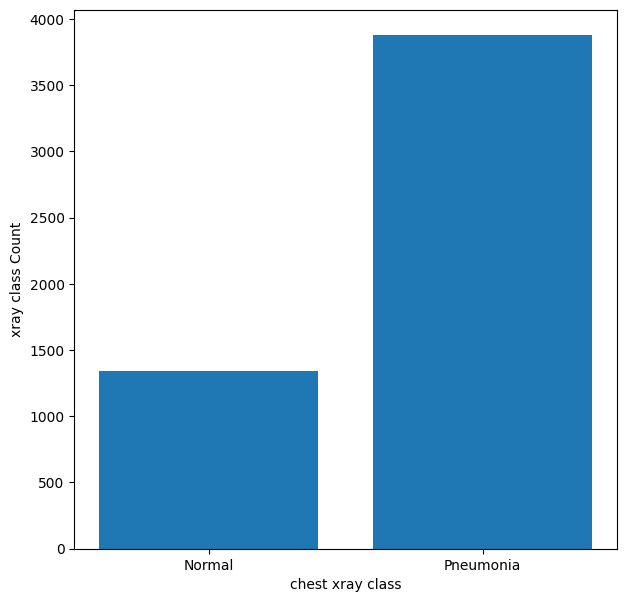

In [38]:
plt.figure(figsize=(7, 7))
plt.bar(classes,train_count)
plt.xlabel("chest xray class")
plt.ylabel("xray class Count")

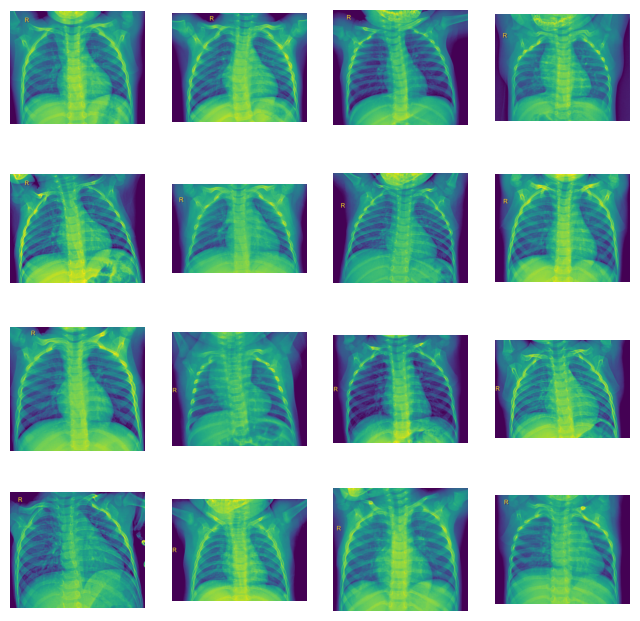

In [39]:
#visualizing normal train images
nrows, ncols = 4, 4
plt.figure(figsize=(8, 8))
for i in range(1, nrows*ncols+1):
  random_image_name  = random.choice(normal_train)
  random_image_path = f"{train_dir}/NORMAL/{random_image_name}"
  image= Image.open(random_image_path)
  plt.subplot(nrows, ncols, i)
  plt.imshow(image)
  plt.axis("OFF")


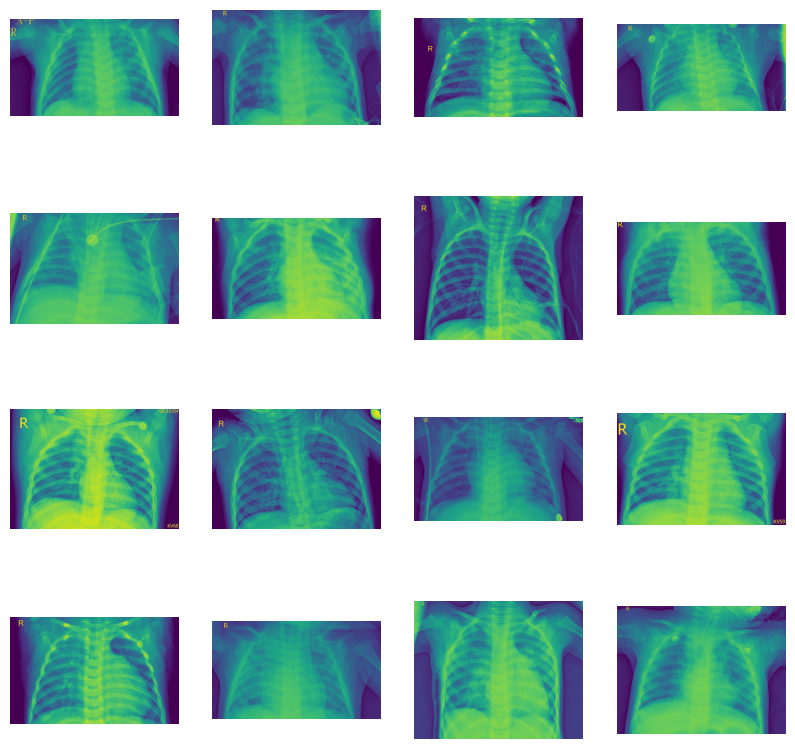

In [40]:
## Visualizing Pneumonia Xray Images
num_cols = 4
num_rows = 4
plt.figure(figsize=(10, 10))
for i in range(1, num_cols*num_rows+1):
  random_image = random.choice(pneumonia_train)
  random_image_name =  f"{train_dir}/PNEUMONIA/{random_image}"
  image = Image.open(random_image_name)
  plt.subplot(num_rows, num_cols, i)
  plt.imshow(image)
  plt.axis("OFF")






image path: /content/machine-learning-projects/chest-x-ray-classification-cnn/chest-xray-pneumonia/chest_xray/train/NORMAL/NORMAL2-IM-0395-0001-0002.jpeg
image format: JPEG
image size: (1416, 1148)


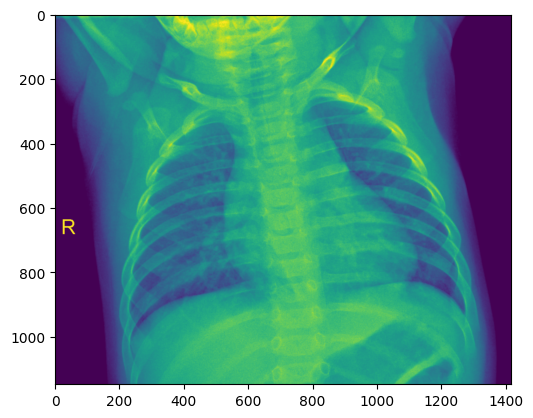

In [41]:
random_normal_xray = random.choice(normal_train)
image_path = f'{train_dir}/NORMAL/{random_normal_xray}'
img = Image.open(image_path)
plt.imshow(img)
print("image path:", image_path)
print("image format:", img.format)
print("image size:", img.size)

In [42]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),

])

test_transforms = transforms.Compose([
    transforms.Resize(size=(256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ]
)

In [43]:

BATCH_SIZE = 32
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False)

In [44]:
print(f'total train data: {len(train_loader)}')
print(f'total test data: {len(test_loader)}')

total train data: 163
total test data: 20


In [45]:
print(f'classes : { train_dataset.classes}')
print(f'classes tndices: { train_dataset.class_to_idx}')

classes : ['NORMAL', 'PNEUMONIA']
classes tndices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [46]:
### Define Model

class XrayNet(nn.Module):
  def __init__(self, NUM_CLASSES=2):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, padding="same"),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same"),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same"),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same"),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3,padding="same"),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2))

    self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
    self.classifier=nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features=256, out_features=128),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(in_features=128, out_features=NUM_CLASSES),
    )

  def forward(self, x):
    x= self.features(x)
    x = self.global_pool(x)
    x =torch.flatten(x, 1)
    x =self.classifier(x)
    return x


In [47]:
def evaluate_model(model, dataloader, metrics, criterion, device):
  model.eval()
  metrics.reset()
  total_loss = 0.0

  with torch.inference_mode():
    for x_batch, y_batch in dataloader:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device).unsqueeze(1).to(torch.float32)
      y_logits= model(x_batch)
      y_prob = torch.sigmoid(y_logits)
      metrics.update(y_logits, y_batch)
      loss = criterion(y_logits, y_batch)
      total_loss += loss.item()
  average_loss = total_loss/ len(dataloader)
  average_metrics = metrics.compute().item()
  return average_loss, average_metrics

def train_model(train_loader, test_loader, model, criterion, optimizer, metrics, epochs, device):
  history = {
        "train_loss" : [],
          "train_acc": [],
          "test_loss": [],
        "test_acc": [],
  }

  best_test_loss = float('inf')
  patience = 5
  epochs_without_improvement = 0
  for epoch in range(epochs):
    train_loss = 0.0
    metrics.reset()
    model.train()
    for x_batch, y_batch in train_loader:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device).unsqueeze(1).to(torch.float32)
      y_logits = model(x_batch)
      y_prob = torch.sigmoid(y_logits)
      loss = criterion(y_logits, y_batch)
      metrics.update(y_prob, y_batch)
      train_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    train_loss /= len(train_loader)
    average_metric = metrics.compute().item()
    history["train_loss"].append(train_loss)
    history["train_acc"].append(average_metric)

    test_loss, test_metrics = evaluate_model(model=model, dataloader=test_loader, metrics=metrics, criterion=criterion, device=device)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_metrics)
    print(f"epoch: {epoch}  train loss: {train_loss} train acc:  {average_metric} \n test loss: {test_loss}  test accuracy : {test_metrics}")

    if test_loss < best_test_loss:
          best_test_loss = test_loss
          epochs_without_improvement = 0
          torch.save(model, "best_model.pth")
          print("best model saved")
    else:
          epochs_without_improvement +=1
          print(f"no improvement "
          f"{epochs_without_improvement}/{patience}")

    if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break
  return history



In [48]:
def initialize_weights(module):
  if isinstance(module, nn.Conv2d):
    nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
    if module.bias is not None:
      nn.init.zeros_(module.bias)
  elif isinstance(module, nn.Linear):
    nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
    nn.init.zeros_(module.bias)
  elif isinstance(module, nn.BatchNorm2d):
    nn.init.ones_(module.weight)
    nn.init.zeros_(module.bias)


In [49]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = XrayNet(NUM_CLASSES=1).to(device=device)
model.apply(initialize_weights)
criterion= nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(params=model.parameters(), lr=1e-4, weight_decay=1e-4)
metrics = torchmetrics.classification.BinaryAccuracy().to(device)
epochs = 10

history = train_model(
    train_loader=train_loader, test_loader=test_loader, model=model, criterion=criterion, optimizer=optimizer, metrics=metrics, epochs=epochs, device=device)


epoch: 0  train loss: 2.5665916462708838 train acc:  0.7492331266403198 
 test loss: 2.065223247464746  test accuracy : 0.7211538553237915
best model saved
epoch: 1  train loss: 1.305133195376835 train acc:  0.7833588719367981 
 test loss: 0.9682141298428177  test accuracy : 0.7660256624221802
best model saved
epoch: 2  train loss: 0.9874766032937115 train acc:  0.7893021702766418 
 test loss: 0.9370255866087973  test accuracy : 0.6842948794364929
best model saved
epoch: 3  train loss: 0.7007018021462154 train acc:  0.8117331266403198 
 test loss: 0.5853942865505815  test accuracy : 0.7788461446762085
best model saved
epoch: 4  train loss: 0.5670077068491216 train acc:  0.8295629024505615 
 test loss: 0.6482067659497261  test accuracy : 0.6746794581413269
no improvement 1/5
epoch: 5  train loss: 0.5244505148083886 train acc:  0.8330138325691223 
 test loss: 0.6615966594778001  test accuracy : 0.7403846383094788
no improvement 2/5
epoch: 6  train loss: 0.44419586281377843 train acc:  0.

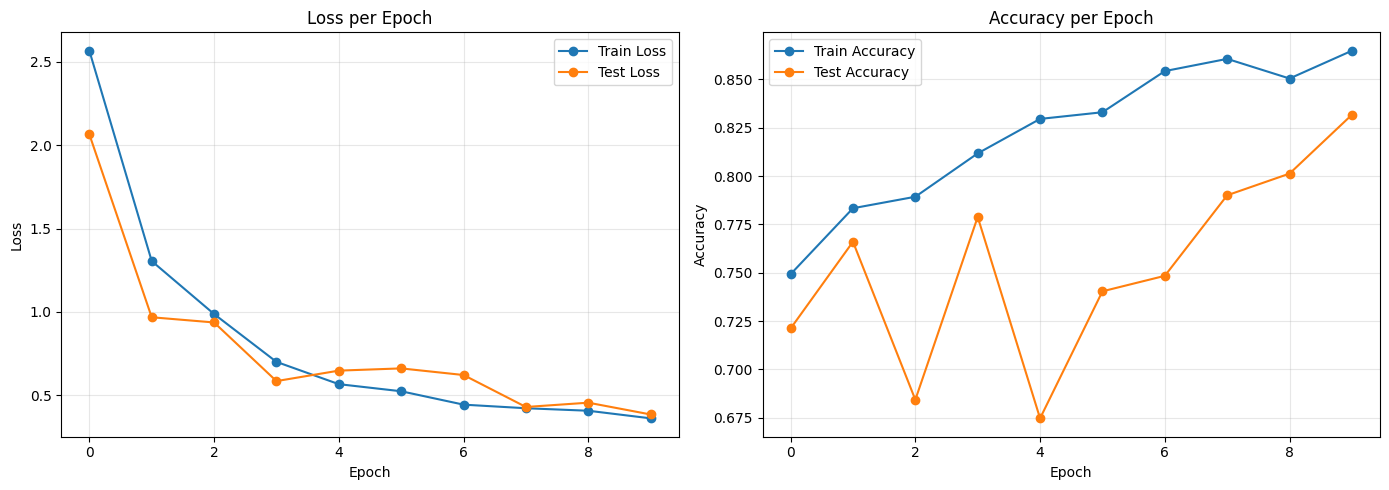

In [52]:

def plot_history(history):
    epochs_range = range(len(history["train_loss"]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker='o')
    axes[0].plot(epochs_range, history["test_loss"], label="Test Loss", marker='o')
    axes[0].set_title("Loss per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)


    axes[1].plot(epochs_range, history["train_acc"], label="Train Accuracy", marker='o')
    axes[1].plot(epochs_range, history["test_acc"], label="Test Accuracy", marker='o')
    axes[1].set_title("Accuracy per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_history(history)

- The model perform pretty descent but suffers from slight overfitting
- This is probably due to small dataset and training with custom CNN
- I will run experiment together with hyperparameter tunning to figure out model best parameters
- Transfer learning will be a very goon solution to this classification task since pretrained models already knows how to detect basic features of image

In [53]:
torch.save(model.state_dict(), "model.pth")